Plot Figure 3b
--

In [1]:
cd ~/Pythons/

/home/users/guicha/Pythons


In [2]:
import numpy as np
import math
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import linregress
from matplotlib.lines import Line2D

from config import IUMFIGDIR
from IUM.read_data.read_data import load_raw_ctrl_surf_var, load_raw_pert_surf_var
from IUM.make_anomalies.twb.make_twb_radius_ctrl_edge_rm import load_twb_radius_ctrl_edge_rm
from IUM.make_anomalies.twb.make_twb_radius_pert_edge_rm import load_twb_radius_pert_edge_rm

Done
Done
Done
Done
Done
Done


In [6]:
var = 'twb'
res = 0.5
value = 0.3
value_pert = 1.
lengths = [25, 30, 35, 50, 75, 100, 125, 150]
u = 4.
env = 'stable'
date = '10010101'
time = 19
window = 3
rcrit = 10.
tb = 15
te = 18

In [7]:
data_ctrl_wet = load_twb_radius_ctrl_edge_rm(res=res, variable=var, value=value_pert, u=u, env=env, date=date, window=window, distance=20.)
twb_ctrl_wet_mean = data_ctrl_wet[20.][0]

pblh_ctrl_wet = load_raw_ctrl_surf_var(res=res, value=value_pert, u=u, env=env, date=date, variable='PBLh')
pblh_ctrl_wet = pblh_ctrl_wet.rolling(T1HR_MN=window, center=True).mean()
pblh_ctrl_wet_mean = pblh_ctrl_wet.mean(dim=['latitude_t', 'longitude_t'])

xs = np.arange(res, 400.+res, res)
ys = xs

xsm, ysm = np.meshgrid(xs, ys)

out_twbs = {}
out_pblhs = {}

for length in lengths:
    print(length) #, end=' : ', flush=True)

    r = length / 2

    d = - length / 4
    data = load_twb_radius_pert_edge_rm(res=res, variable=var, value=value, value_pert=value_pert, length=length, u=u, env=env, date=date, window=window, distance=d)

    pblh_pert = load_raw_pert_surf_var(res=res, value=value, value_pert=value_pert, length=length, u=u, env=env, date=date, variable='PBLh')
    pblh_pert = pblh_pert.rolling(T1HR_MN=window, center=True).mean()

    # Sample PBLh area with fixed radius
    xc = (xs[-1] - xs[0]) / 2 + res / 2 + r / 2   # centre of the averaging area along the x-axis
    yc = (ys[-1] - ys[0]) / 2 + res / 2
    distloc = ( ((xsm - xc) * (xsm - xc)) + ((ysm - yc) * (ysm - yc)) )**.5
    disc_mask = np.broadcast_to(distloc <= rcrit, pblh_pert.shape)   # True in disc

    # Sample PBLh over wet patch
    xc = (xs[-1] - xs[0]) / 2 + res / 2   # centre of the averaging area along the x-axis
    yc = (ys[-1] - ys[0]) / 2 + res / 2
    distloc = ( ((xsm - xc) * (xsm - xc)) + ((ysm - yc) * (ysm - yc)) )**.5

    pblh_pert_wet = pblh_pert.where(disc_mask)
    pblh_pert_wet_mean = pblh_pert_wet.mean(dim=['latitude_t', 'longitude_t'])

    tgrad_pblh = np.gradient(pblh_pert_wet_mean)

    twbs_r = data[rcrit][0]

    out_twbs[length] = twbs_r
    out_pblhs[length] = pblh_pert_wet_mean

twb_ctrl_wet_mean_t = twb_ctrl_wet_mean.isel(time=time-1).values
pblh_ctrl_wet_mean_t = pblh_ctrl_wet_mean.isel(T1HR_MN=slice(tb-1, te)).mean().values  #htwb_max_mean).values

twbs = np.asarray([twb.isel(time=time-1).values for twb in out_twbs.values()])
pblhs = np.asarray([pblh.isel(T1HR_MN=slice(tb-1, te)).mean().values for pblh in out_pblhs.values()])

twb_min = min(twbs)
twb_max = max(twbs)
twb_med = np.median(twbs)
pblhs_min = min(pblhs)
pblhs_max = max(pblhs)
pblhs_med = np.median(pblhs)

x = np.linspace(pblhs_min, pblhs_max, 100)

lr = linregress(pblhs, twbs)
k = lr[0]
b = lr[1]
y = x * k + b
r2 = lr.rvalue**2
pval = lr.pvalue

if pval < 0.01:
    sym = '$p < 0.01$'
elif 0.01 <= pval < 0.05:
    sym = '$p < 0.05$'
elif 0.05 <= pval < 0.1:
    sym = '$p < 0.1$'
else:
    sym = ''

25
30
35
50
75
100
125
150


(8, 0.687225249308318, 0.01095390648699029):(9, 0.6986562884002865, 0.00973987677286255):(10, 0.4555106261204461, 0.06630841479132496):(11, 0.025756235069074363, 0.7042129702817256):(12, 0.18696700401734756, 0.28464271549055475):(13, 0.3260832525776047, 0.1392931833941116):(14, 0.1981134374340389, 0.2691127822054478):(15, 0.05295416768063292, 0.5835193989024148):(16, 0.06144940761380512, 0.5538962635442156):(17, 0.5268515889644756, 0.04150279044575729):(18, 0.7338346757323103, 0.0065963977794112295):(19, 0.8399133869478322, 0.001367373903830468):(20, 0.7664375945958117, 0.004388845644863517):(21, 0.6766771268122065, 0.012165394071634732):

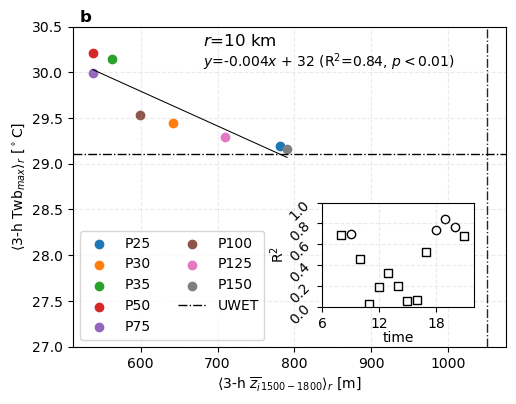

In [8]:
if var == 'twb':
    ylims = (27., 30.5)
    var_ = 'Twb'
    flab = 'b'
elif var == 'hi':
    ylims = (40., 50.)
    var_ = 'HI'
    flab = ''

rcrit_ = str(int(rcrit))

fig, ax = plt.subplots()

plt.subplots_adjust(top=0.925, bottom=0.125, right=0.95)

for i, (pblh, twb) in enumerate(zip(pblhs, twbs)):
    ax.scatter(pblh, twb, label='P%i'%lengths[i])

ax.plot(x, y, lw=0.75, color='k')

ax.axhline(twb_ctrl_wet_mean_t, 0, 1, color='k', lw=1., ls='-.', label='UWET')
ax.axvline(pblh_ctrl_wet_mean_t, 0, 1, color='k', lw=1., ls='-.', alpha=0.85)

ax.text(0.015, 1.015, flab, weight='bold', fontsize=12, transform=ax.transAxes)
ax.text(0.3, 0.875, '$y$=%.3f$x$ + %1.f (R$^2$=%.2f, %s)'%(k, b, r2, sym), transform=ax.transAxes)
ax.text(0.3, 0.94, '$r$=%s km'%rcrit_, fontsize=12, transform=ax.transAxes)

axins = ax.inset_axes([0.575, 0.125, 0.35, 0.325])

ts = np.arange(8, 21+1, 1)

for t in ts:
    twbs_t = np.asarray([twb.isel(time=t-1).values for twb in out_twbs.values()])
    pblhs_t = np.asarray([pblh.isel(T1HR_MN=slice(t-4, t-1)).mean().values for pblh in out_pblhs.values()])

    lr_ = linregress(pblhs_t, twbs_t)
    k_ = lr_[0]
    b_ = lr_[1]
    r2_ = lr_.rvalue**2
    pval_ = lr_.pvalue

    print((t, r2_, pval_), end=':', flush=True)

    if pval_ <= 0.01:
        mrk = 'o'
    else:
        mrk = 's'

    axins.scatter(t, r2_, marker=mrk, color='w', edgecolors='k')

xtcks2 = np.arange(6, 18+6, 6)
ytcks2 = np.arange(0., 1+0.2, 0.2)
ytlbs2 = [str(round(yt,1)) for yt in ytcks2]

axins.set_xlim(6, 22)
axins.set_xticks(xtcks2)
axins.set_xlabel('time', labelpad=0.075)
axins.set_yticks(ytcks2)
axins.set_yticklabels(ytlbs2, rotation=45)
axins.set_ylim(0., 1.)
axins.set_ylabel('R$^2$', labelpad=0.075)
axins.grid(True, ls='--', alpha=0.25)

ax.set_xlabel('$\\langle$3-h $\\overline{z_i}_{%i00-%i00}\\rangle_{r}$ [m]'%(tb, te))
ax.set_ylim(ylims)
ax.set_ylabel('$\\langle$3-h %s$_{max}\\rangle_{r}$ [$^\circ$C]'%var_)
ax.grid(True, ls='--', alpha=0.25)
ax.legend(loc='lower left', ncol=2)  # upper center'

fig.set_size_inches(5.25, 4.)